# 01 — Data Exploration

**Goal:** Get familiar with the play-by-play data. Understand what a game looks like as a stochastic process before we model it.

**What we're looking at:**
- Score margin over time for individual games
- Distribution of margin changes per minute (this is the σ we'll estimate)
- Whether the data looks clean (monotonic scores, no missing quarters, etc.)

**Prerequisites:** Run `python -m infra.db.init_db` and load at least one season with `/load-season`.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import sys
sys.path.insert(0, str(Path('..').resolve()))  # so we can import infra/notebooks

from infra.db import queries

DB_PATH = '../data/quant_lab.db'

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

print('Setup complete.')

Setup complete.


**Set up an additional DataFrame for NBA Team Names**:

In [2]:
from nba_api.stats.static import teams as nba_teams_static

nba_teams = nba_teams_static.get_teams()
teams_df = pd.DataFrame(nba_teams)[['id', 'full_name', 'abbreviation']]
teams_df['id'] = teams_df['id'].astype(str)
teams_df = teams_df.rename(columns={'id': 'team_id', 'full_name': 'team_name'})

In [3]:
teams_df.head()

,team_id,team_name,abbreviation
0,1610612737,Atlanta Hawks,ATL
1,1610612738,Boston Celtics,BOS
2,1610612739,Cleveland Cavaliers,CLE
3,1610612740,New Orleans Pelicans,NOP
4,1610612741,Chicago Bulls,CHI


## 1. What games do we have?

Check how many games are in the database and their date range.

In [4]:
games = queries.get_games(DB_PATH, league='NBA')
print(f"Total NBA games: {len(games)}")
print(f"Date range: {games['game_date'].min()} → {games['game_date'].max()}")
print(f"Seasons: {sorted(games['season'].unique())}")
# games.head()

Total NBA games: 1225
Date range: 2024-10-22 → 2025-04-13
Seasons: ['2024-25']


**Merge the DataFrames so we have access to the names of the NBA teams as well:**

In [5]:
# Add home/away team names to games
games = games.merge(teams_df.rename(columns={'team_id': 'home_team_id', 'team_name': 'home_team_name', 'abbreviation': 'home_abbrev'}), on='home_team_id', how='left')
games = games.merge(teams_df.rename(columns={'team_id': 'away_team_id', 'team_name': 'away_team_name', 'abbreviation': 'away_abbrev'}), on='away_team_id', how='left')

games.head()

,game_id,league,season,game_date,home_team_id,away_team_id,home_final_score,away_final_score,pre_game_spread,pre_game_total,status,home_team_name,home_abbrev,away_team_name,away_abbrev
0,0022400061,NBA,2024-25,2024-10-22,1610612738,1610612752,NaN,NaN,None,None,final,Boston Celtics,BOS,New York Knicks,NYK
1,0022400062,NBA,2024-25,2024-10-22,1610612747,1610612750,NaN,NaN,None,None,final,Los Angeles Lakers,LAL,Minnesota Timberwolves,MIN
2,0022400069,NBA,2024-25,2024-10-23,1610612740,1610612741,123.0,111.0,None,None,final,New Orleans Pelicans,NOP,Chicago Bulls,CHI
3,0022400065,NBA,2024-25,2024-10-23,1610612748,1610612753,97.0,116.0,None,None,final,Miami Heat,MIA,Orlando Magic,ORL
4,0022400072,NBA,2024-25,2024-10-23,1610612757,1610612744,104.0,140.0,None,None,final,Portland Trail Blazers,POR,Golden State Warriors,GSW


In [6]:
games.iloc[50:70]

,game_id,league,season,game_date,home_team_id,away_team_id,home_final_score,away_final_score,pre_game_spread,pre_game_total,status,home_team_name,home_abbrev,away_team_name,away_abbrev
50,0022400107,NBA,2024-25,2024-10-28,1610612761,1610612743,NaN,NaN,None,None,final,Toronto Raptors,TOR,Denver Nuggets,DEN
51,0022400105,NBA,2024-25,2024-10-28,1610612748,1610612765,NaN,NaN,None,None,final,Miami Heat,MIA,Detroit Pistons,DET
52,0022400116,NBA,2024-25,2024-10-29,1610612744,1610612740,NaN,NaN,None,None,final,Golden State Warriors,GSW,New Orleans Pelicans,NOP
53,0022400115,NBA,2024-25,2024-10-29,1610612762,1610612758,NaN,NaN,None,None,final,Utah Jazz,UTA,Sacramento Kings,SAC
54,0022400113,NBA,2024-25,2024-10-29,1610612751,1610612743,NaN,NaN,None,None,final,Brooklyn Nets,BKN,Denver Nuggets,DEN
55,0022400114,NBA,2024-25,2024-10-29,1610612750,1610612742,NaN,NaN,None,None,final,Minnesota Timberwolves,MIN,Dallas Mavericks,DAL
56,0022400124,NBA,2024-25,2024-10-30,1610612763,1610612751,NaN,NaN,None,None,final,Memphis Grizzlies,MEM,Brooklyn Nets,BKN
57,0022400117,NBA,2024-25,2024-10-30,1610612766,1610612761,NaN,NaN,None,None,final,Charlotte Hornets,CHA,Toronto Raptors,TOR
58,0022400126,NBA,2024-25,2024-10-30,1610612744,1610612740,NaN,NaN,None,None,final,Golden State Warriors,GSW,New Orleans Pelicans,NOP
59,0022400127,NBA,2024-25,2024-10-30,1610612746,1610612757,NaN,NaN,None,None,final,Los Angeles Clippers,LAC,Portland Trail Blazers,POR


### Divide the games into months for convenience

In [7]:
october_games  = games[(games['game_date'] >= '2024-10-01') & (games['game_date'] <= '2024-10-31')]
november_games = games[(games['game_date'] >= '2024-11-01') & (games['game_date'] <= '2024-11-30')]
december_games = games[(games['game_date'] >= '2024-12-01') & (games['game_date'] <= '2024-12-31')]
january_games  = games[(games['game_date'] >= '2025-01-01') & (games['game_date'] <= '2025-01-31')]
february_games = games[(games['game_date'] >= '2025-02-01') & (games['game_date'] <= '2025-02-28')]
march_games    = games[(games['game_date'] >= '2025-03-01') & (games['game_date'] <= '2025-03-31')]
april_games    = games[(games['game_date'] >= '2025-04-01') & (games['game_date'] <= '2025-04-30')]

In [8]:
april_games[(april_games['game_date'] == '2025-04-06')]

,game_id,league,season,game_date,home_team_id,away_team_id,home_final_score,away_final_score,pre_game_spread,pre_game_total,status,home_team_name,home_abbrev,away_team_name,away_abbrev
1157,0022401143,NBA,2024-25,2025-04-06,1610612744,1610612745,NaN,NaN,None,None,final,Golden State Warriors,GSW,Houston Rockets,HOU
1158,0022401135,NBA,2024-25,2025-04-06,1610612760,1610612747,NaN,NaN,None,None,final,Oklahoma City Thunder,OKC,Los Angeles Lakers,LAL
1159,0022401136,NBA,2024-25,2025-04-06,1610612737,1610612762,NaN,NaN,None,None,final,Atlanta Hawks,ATL,Utah Jazz,UTA
1160,0022401134,NBA,2024-25,2025-04-06,1610612751,1610612761,NaN,NaN,None,None,final,Brooklyn Nets,BKN,Toronto Raptors,TOR
1161,0022401142,NBA,2024-25,2025-04-06,1610612743,1610612754,NaN,NaN,None,None,final,Denver Nuggets,DEN,Indiana Pacers,IND
1162,0022401133,NBA,2024-25,2025-04-06,1610612766,1610612741,NaN,NaN,None,None,final,Charlotte Hornets,CHA,Chicago Bulls,CHI
1163,0022401139,NBA,2024-25,2025-04-06,1610612757,1610612759,NaN,NaN,None,None,final,Portland Trail Blazers,POR,San Antonio Spurs,SAS
1164,0022401140,NBA,2024-25,2025-04-06,1610612752,1610612756,NaN,NaN,None,None,final,New York Knicks,NYK,Phoenix Suns,PHX
1165,0022401138,NBA,2024-25,2025-04-06,1610612739,1610612758,NaN,NaN,None,None,final,Cleveland Cavaliers,CLE,Sacramento Kings,SAC
1166,0022401137,NBA,2024-25,2025-04-06,1610612738,1610612764,NaN,NaN,None,None,final,Boston Celtics,BOS,Washington Wizards,WAS


## 2. Score margin over time — a single game

Plot home − away score margin as a function of elapsed minutes for one game.
If our Brownian motion model is reasonable, this should look like a random walk with drift.

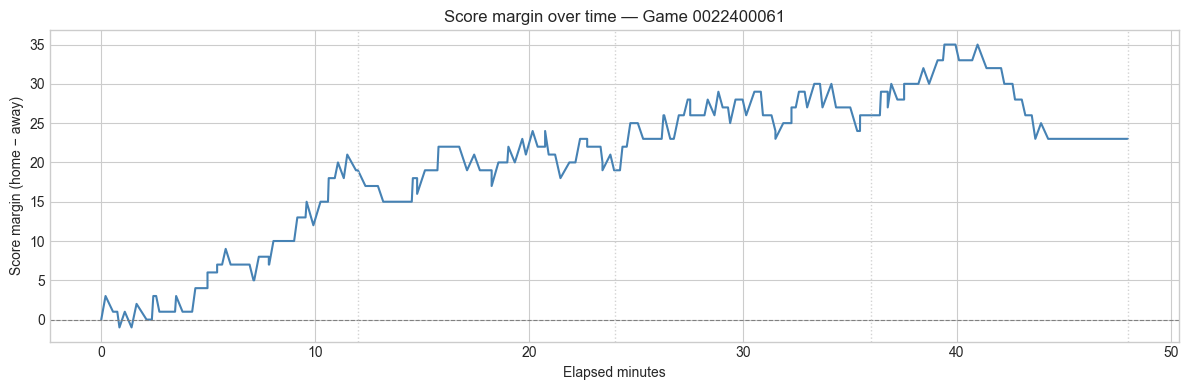

Final margin: 23 (home win)


In [9]:
# Pick a sample game
sample_game_id = games.iloc[0]['game_id']
pbp = queries.get_play_by_play(DB_PATH, sample_game_id)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pbp['elapsed_minutes'], pbp['score_margin'], linewidth=1.5, color='steelblue')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Mark quarter breaks
for q_end in [12, 24, 36, 48]:
    ax.axvline(q_end, color='lightgray', linestyle=':', linewidth=1)

ax.set_xlabel('Elapsed minutes')
ax.set_ylabel('Score margin (home − away)')
ax.set_title(f'Score margin over time — Game {sample_game_id}')
plt.tight_layout()
plt.show()

print(f"Final margin: {pbp['score_margin'].iloc[-1]} ({'home win' if pbp['score_margin'].iloc[-1] > 0 else 'away win'})")

### NOTE: INPUT THE game_id AS A STRING, INLCUDING THE ZEROS!

In [10]:
# here's a function for the time-series display like above.

def plot_game_margin(game_id):
    pbp = queries.get_play_by_play(DB_PATH, game_id)
    
    if pbp.empty:
        print(f"No play-by-play data found for game {game_id}")
        return
    
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(pbp['elapsed_minutes'], pbp['score_margin'], linewidth=1.5, color='steelblue')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    
    for q_end in [12, 24, 36, 48]:
        ax.axvline(q_end, color='lightgray', linestyle=':', linewidth=1)
    
    ax.set_xlabel('Elapsed minutes')
    ax.set_ylabel('Score margin (home − away)')
    ax.set_title(f'Score margin over time — Game {game_id}')
    plt.tight_layout()
    plt.show()
    
    final_margin = pbp['score_margin'].iloc[-1]
    outcome = 'home win' if final_margin > 0 else 'away win'
    print(f"Final margin: {final_margin} ({outcome})")


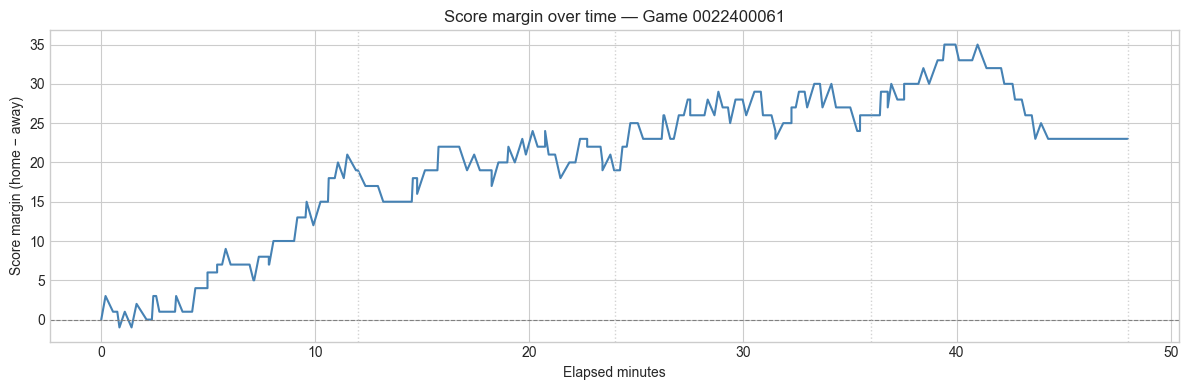

Final margin: 23 (home win)


In [11]:
plot_game_margin(sample_game_id)

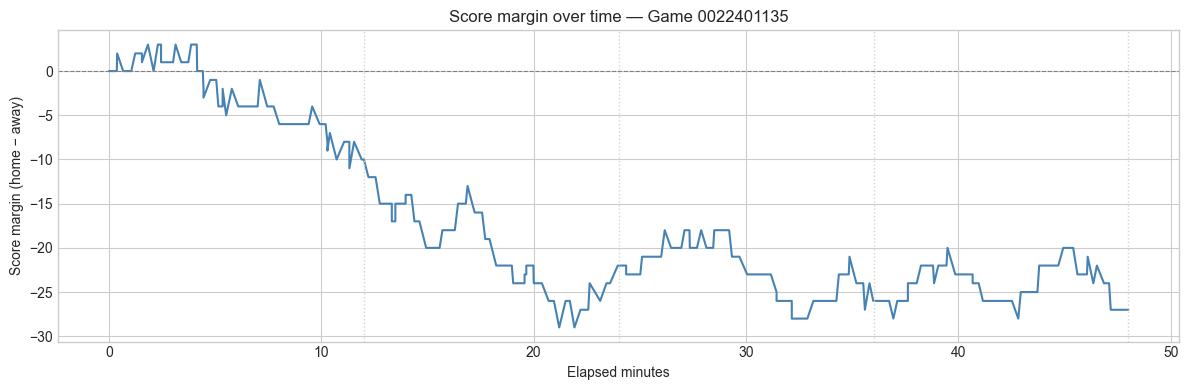

Final margin: -27 (away win)


In [12]:
plot_game_margin('0022401135') # LA Lakers vs. Oklahoma City Thunder on April 6, 2025 (blowout game)

In [13]:
games.iloc[150]['game_id']

'0022400216'

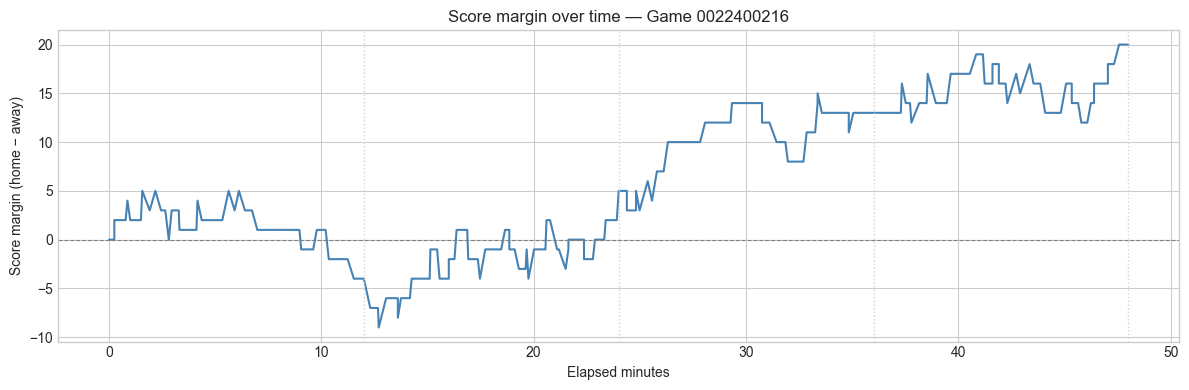

Final margin: 20 (home win)


In [14]:
plot_game_margin(games.iloc[150]['game_id']) # example of a blowout game (Game 0022400738) another blowout game

In [15]:
plot_game_margin(22400738)

No play-by-play data found for game 22400738


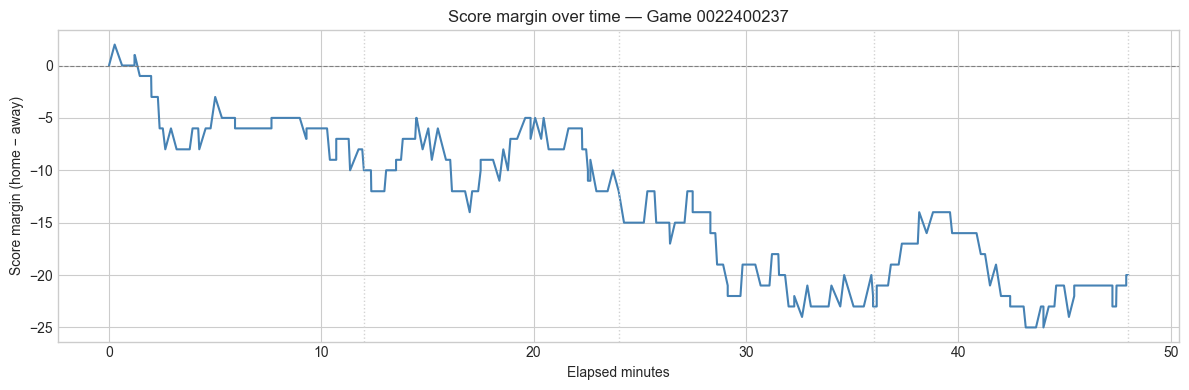

Final margin: -20 (away win)


In [16]:
# trying to find a game with a comeback
plot_game_margin(games.iloc[201]['game_id']) # game 0022400790

In [17]:
games[games['game_id'] == '0022400790'].iloc[0]

game_id                0022400790
league                        NBA
season                    2024-25
game_date              2025-02-20
home_team_id           1610612737
away_team_id           1610612753
home_final_score              NaN
away_final_score              NaN
pre_game_spread              None
pre_game_total               None
status                      final
home_team_name      Atlanta Hawks
home_abbrev                   ATL
away_team_name      Orlando Magic
away_abbrev                   ORL
Name: 810, dtype: object

The game above is a time series for a close game. Below, I'll find games that were blowouts and ones that were comebacks in order to see how the time series look.

## Plotting play-by-play scores

Here, along with Claude, we've created a function to plot the play-by-play scores of both teams in a game (specified by game_id). At the end, it also prints out the final scores.

In [18]:
def plot_team_scores(game_id):
    pbp = queries.get_play_by_play(DB_PATH, game_id)
    
    if pbp.empty:
        print(f"No play-by-play data found for game {game_id}")
        return
    
    scored = pbp[pbp['home_score'].notna() & pbp['away_score'].notna()].copy()
    
    if scored.empty:
        print(f"No score data found in PBP for game {game_id}")
        return

    # Look up team names from games DataFrame
    game_row = games[games['game_id'] == game_id]
    if game_row.empty:
        home_name, away_name = 'Home', 'Away'
    else:
        home_name = game_row.iloc[0]['home_team_name']
        away_name = game_row.iloc[0]['away_team_name']

    fig, ax = plt.subplots(figsize=(12, 4))
    
    ax.plot(scored['elapsed_minutes'], scored['home_score'], linewidth=1.5, color='steelblue', label=home_name)
    ax.plot(scored['elapsed_minutes'], scored['away_score'], linewidth=1.5, color='red', label=away_name)
    
    for q_end in [12, 24, 36, 48]:
        ax.axvline(q_end, color='lightgray', linestyle=':', linewidth=1)
    
    ax.set_xlabel('Elapsed minutes')
    ax.set_ylabel('Score')
    ax.set_title(f'{home_name} vs {away_name} — Game {game_id}')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    last = scored.iloc[-1]
    home_score = int(last['home_score'])
    away_score = int(last['away_score'])
    winner = home_name if home_score > away_score else away_name
    print(f"Final Score — {home_name}: {home_score} | {away_name}: {away_score} ({winner} win)")

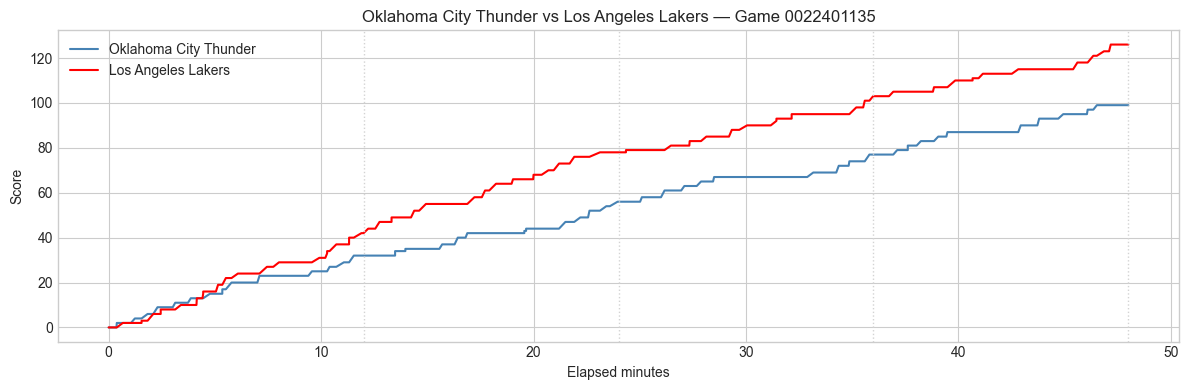

Final Score — Oklahoma City Thunder: 99 | Los Angeles Lakers: 126 (Los Angeles Lakers win)


In [19]:
plot_team_scores('0022401135')

## 3. Distribution of margin changes

The key question: **what does dX(t) look like?**

If score differential is Brownian motion with constant σ, the 1-minute margin changes should be approximately normally distributed with mean ≈ 0 and std ≈ σ.

In [20]:
# Load PBP for all games to get the full distribution
pbp_all = queries.get_play_by_play_for_sigma(DB_PATH, league='NBA')
print(f"Total PBP rows: {len(pbp_all):,}")
print(f"Games covered: {pbp_all['game_id'].nunique():,}")
pbp_all.head()

Total PBP rows: 603,951
Games covered: 1,225


,game_id,elapsed_minutes,score_margin,quarter
0,0022400001,0.000000,0,1
1,0022400001,0.000000,0,1
2,0022400001,0.283333,0,1
3,0022400001,0.283333,0,1
4,0022400001,0.300000,0,1


In [21]:
# Compute 1-minute margin changes within each game
pbp_all = pbp_all.sort_values(['game_id', 'elapsed_minutes'])

# Bucket elapsed_minutes into 1-minute intervals
pbp_all['minute_bucket'] = pbp_all['elapsed_minutes'].apply(lambda x: int(x))

# For each game, take the last margin reading per minute bucket
minute_margins = (
    pbp_all
    .groupby(['game_id', 'minute_bucket'])['score_margin']
    .last()
    .reset_index()
)

# Compute first differences within each game
minute_margins['margin_change'] = minute_margins.groupby('game_id')['score_margin'].diff()
changes = minute_margins['margin_change'].dropna()

print(f"1-min margin changes:")
print(f"  Mean:  {changes.mean():.3f}  (should be near 0 for a balanced dataset)")
print(f"  Std:   {changes.std():.3f}  ← this is our empirical σ")
print(f"  N:     {len(changes):,}")

1-min margin changes:
  Mean:  0.035  (should be near 0 for a balanced dataset)
  Std:   2.627  ← this is our empirical σ
  N:     59,120


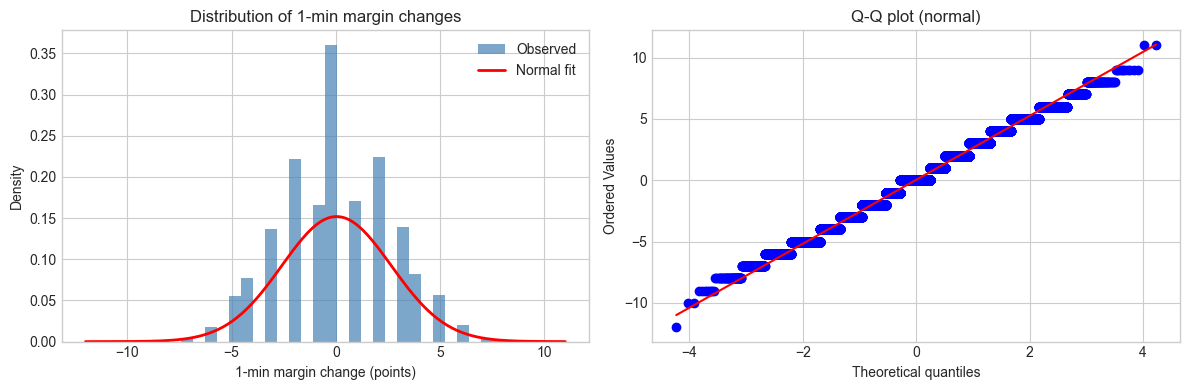

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with normal overlay
from scipy.stats import norm
ax = axes[0]
ax.hist(changes, bins=40, density=True, alpha=0.7, color='steelblue', label='Observed')
x = np.linspace(changes.min(), changes.max(), 200)
ax.plot(x, norm.pdf(x, changes.mean(), changes.std()), 'r-', linewidth=2, label='Normal fit')
ax.set_xlabel('1-min margin change (points)')
ax.set_ylabel('Density')
ax.set_title('Distribution of 1-min margin changes')
ax.legend()

# Q-Q plot to check normality
from scipy.stats import probplot
ax2 = axes[1]
probplot(changes, dist='norm', plot=ax2)
ax2.set_title('Q-Q plot (normal)')

plt.tight_layout()
plt.show()

## 4. Summary stats

Collect the numbers we'll need for model calibration in the next notebook.

In [23]:
sigma_empirical = changes.std()

print("=" * 40)
print("SUMMARY FOR MODEL CALIBRATION")
print("=" * 40)
print(f"Empirical σ (1-min):  {sigma_empirical:.4f} points/√min")
print(f"Games in dataset:     {pbp_all['game_id'].nunique():,}")
print()
print("Take these numbers to 02_parameter_estimation.ipynb for formal estimation.")

SUMMARY FOR MODEL CALIBRATION
Empirical σ (1-min):  2.6269 points/√min
Games in dataset:     1,225

Take these numbers to 02_parameter_estimation.ipynb for formal estimation.
